In [1]:
# ============================================================
# 1. INSTALL / IMPORTS
# ============================================================
%pip install -q py7zr scikit-learn

import os
import json
import copy
import time
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import py7zr

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.7 MB/s eta 0:00:00


In [3]:
import zipfile

zip_file_path = "/content/datasets_split.zip"
extract_to_path = "."

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

print(f"'{zip_file_path}' decompressed to '{extract_to_path}'")
print("Content of current directory after extraction:", os.listdir(extract_to_path))

'/content/datasets_split.zip' decompressed to '.'
Content of current directory after extraction: ['.config', '__MACOSX', 'datasets_split.zip', 'datasets_split', 'sample_data']


In [4]:
# ============================================================
# 2. PARAMETRES
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3
NUM_WORKERS = 2
PATIENCE = 8

MODEL_NAME = "CNN"
DATASET_NAME = "long_range"   # ou "texture"
JSON_PATH = f"./{MODEL_NAME.lower()}_{DATASET_NAME}_results.json"

print("Device:", DEVICE)

Device: cuda


In [5]:
# ============================================================
# 4. CHOISIR LE BON DATASET ROOT
# ============================================================
# Ici on choisit manuellement la bonne extraction
# Mets le bon chemin selon ce que tu veux utiliser
DATASET_ROOT = "./datasets_split"

print("DATASET_ROOT =", DATASET_ROOT)
print("Contenu :", os.listdir(DATASET_ROOT))

DATASET_ROOT = ./datasets_split
Contenu : ['.DS_Store', 'train', 'classes.txt', 'test', 'val']


In [ ]:
# ============================================================
# 6. TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
# ============================================================
# 7. DATASETS / DATALOADERS
# ============================================================
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_ROOT, "train","long_range"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_ROOT, "test", "long_range"),
    transform=val_transform
)

print("Classes train:", train_dataset.classes)
print("Classes val  :", val_dataset.classes)

# Vérification importante
assert train_dataset.classes == val_dataset.classes, "Les classes train/val ne correspondent pas !"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("Nombre de classes:", num_classes)
print("Taille train:", len(train_dataset))
print("Taille val:", len(val_dataset))

Classes train: ['0', '1', '2', '3', '4']
Classes val  : ['0', '1', '2', '3', '4']
Nombre de classes: 5
Taille train: 1750
Taille val: 375


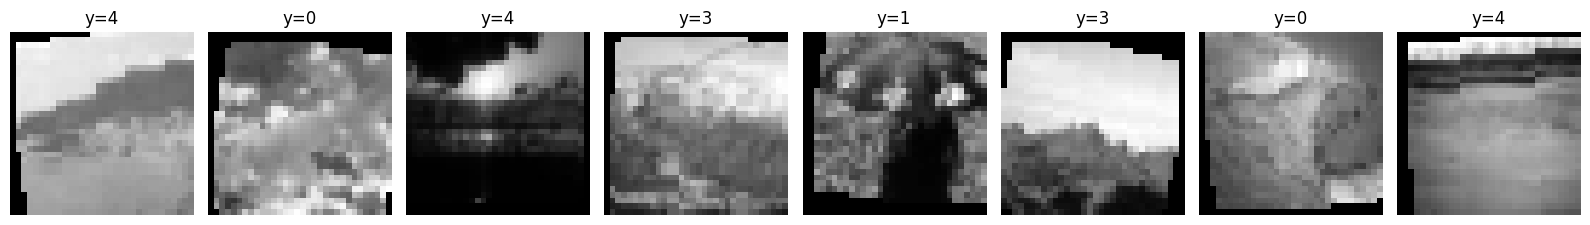

In [8]:
def show_batch(loader):
    images, labels = next(iter(loader))
    images = images[:8]
    labels = labels[:8]

    fig, axes = plt.subplots(1, len(images), figsize=(16, 3))
    for i in range(len(images)):
        axes[i].imshow(images[i][0], cmap="gray")
        axes[i].set_title(f"y={labels[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [9]:
# ============================================================
# 9. MODELE CNN
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
# ============================================================
# 10. FONCTIONS UTILES
# ============================================================
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
# ============================================================
# 11. TRAIN / EVAL
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (preds == labels).sum().item()
        total_samples += batch_size

    train_loss = running_loss / total_samples
    train_acc = correct / total_samples

    return float(train_loss), float(train_acc)

In [12]:
# ============================================================
# 11. TRAIN / EVAL
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (preds == labels).sum().item()
        total_samples += batch_size

    train_loss = running_loss / total_samples
    train_acc = correct / total_samples

    return float(train_loss), float(train_acc)

In [13]:
# ============================================================
# 12. EVALUATION COMPLETE
# ============================================================
@torch.no_grad()
def evaluate_full(model, loader, criterion, device, class_names=None):
    model.eval()

    running_loss = 0.0
    total_samples = 0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    val_loss = running_loss / total_samples
    val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    val_f1 = f1_score(all_labels, all_preds, average="macro")

    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    if class_names is None:
        class_names = [str(i) for i in range(len(precision))]

    per_class = {}
    for i, class_name in enumerate(class_names):
        per_class[class_name] = {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1_per_class[i]),
            "support": int(support[i])
        }

    return {
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "val_f1": float(val_f1),
        "per_class": per_class,
        "confusion_matrix": cm.tolist()
    }

In [20]:
# ============================================================
# 13. TRAINING + JSON
# ============================================================
def train_model_with_json(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    device,
    model_name,
    dataset_name,
    class_names,
    json_path,
    patience=8
):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    results = {
        "model": model_name,
        "dataset": dataset_name,
        "n_params": int(count_trainable_params(model)),
        "history": [],
        "best_epoch": None,
        "best_val_acc": None,
        "best_val_f1": None,
        "per_class_metrics": None,
        "confusion_matrix": None,
        "class_names": class_names
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    best_val_f1 = -1.0
    best_epoch = -1
    best_per_class = None
    best_confusion_matrix = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_results = evaluate_full(
            model, val_loader, criterion, device, class_names=class_names
        )

        val_loss = val_results["val_loss"]
        val_acc = val_results["val_acc"]
        val_f1 = val_results["val_f1"]
        per_class = val_results["per_class"]
        cm = val_results["confusion_matrix"]

        current_lr = optimizer.param_groups[0]["lr"]

        results["history"].append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_acc": float(train_acc),
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "val_f1": float(val_f1),
            "lr": float(current_lr)
        })

        print(
            f"Epoch [{epoch}/{epochs}] | "
            f"lr={current_lr:.6f} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}"
        )

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_wts = copy.deepcopy(model.state_dict())
            best_per_class = per_class
            best_confusion_matrix = cm
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping à l'époque {epoch}")
            break

    total_time = time.time() - start_time
    model.load_state_dict(best_model_wts)

    results["best_epoch"] = int(best_epoch)
    results["best_val_acc"] = float(best_val_acc)
    results["best_val_f1"] = float(best_val_f1)
    results["per_class_metrics"] = best_per_class
    results["confusion_matrix"] = best_confusion_matrix
    results["training_time_sec"] = float(total_time)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    print(f"\nMeilleure val_acc: {best_val_acc:.4f}")
    print(f"Meilleure val_f1 : {best_val_f1:.4f}")
    print(f"Best epoch       : {best_epoch}")
    print(f"Temps total      : {total_time:.2f} sec")
    print(f"JSON sauvegardé  : {json_path}")

    return model, results

In [15]:
# ============================================================
# 14. MATRICE DE CONFUSION
# ============================================================
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

In [21]:
# ============================================================
# 15. LANCER L'ENTRAINEMENT
# ============================================================
cnn_model = SimpleCNN(num_classes=num_classes).to(DEVICE)

cnn_model, results = train_model_with_json(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
    model_name=MODEL_NAME,
    dataset_name=DATASET_NAME,
    class_names=class_names,
    json_path=JSON_PATH,
    patience=PATIENCE
)

Epoch [1/40] | lr=0.001000 | train_loss=1.5175 | train_acc=0.3286 | val_loss=1.6772 | val_acc=0.3413 | val_f1=0.2535
Epoch [2/40] | lr=0.001000 | train_loss=1.3766 | train_acc=0.4200 | val_loss=1.2787 | val_acc=0.4507 | val_f1=0.4041
Epoch [3/40] | lr=0.001000 | train_loss=1.3268 | train_acc=0.4389 | val_loss=1.1678 | val_acc=0.5333 | val_f1=0.5289
Epoch [4/40] | lr=0.001000 | train_loss=1.2572 | train_acc=0.4920 | val_loss=1.4047 | val_acc=0.4613 | val_f1=0.4287
Epoch [5/40] | lr=0.001000 | train_loss=1.2292 | train_acc=0.4869 | val_loss=0.9922 | val_acc=0.6107 | val_f1=0.6050
Epoch [6/40] | lr=0.001000 | train_loss=1.1819 | train_acc=0.5309 | val_loss=0.9959 | val_acc=0.6267 | val_f1=0.6259
Epoch [7/40] | lr=0.001000 | train_loss=1.1401 | train_acc=0.5457 | val_loss=0.9377 | val_acc=0.6240 | val_f1=0.6072
Epoch [8/40] | lr=0.001000 | train_loss=1.1406 | train_acc=0.5411 | val_loss=0.9398 | val_acc=0.6640 | val_f1=0.6652
Epoch [9/40] | lr=0.001000 | train_loss=1.1350 | train_acc=0.541

In [17]:
# ============================================================
# 16. AFFICHER LES METRIQUES PAR CLASSE
# ============================================================
print("\n=== Metrics par classe ===")
for class_name, metrics in results["per_class_metrics"].items():
    print(
        f"{class_name} | "
        f"precision={metrics['precision']:.4f} | "
        f"recall={metrics['recall']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"support={metrics['support']}"
    )


=== Metrics par classe ===
0 | precision=0.6882 | recall=0.8533 | f1=0.7619 | support=75
1 | precision=0.7206 | recall=0.6533 | f1=0.6853 | support=75
2 | precision=0.8481 | recall=0.8933 | f1=0.8701 | support=75
3 | precision=0.6857 | recall=0.6400 | f1=0.6621 | support=75
4 | precision=0.8154 | recall=0.7067 | f1=0.7571 | support=75


In [19]:
# ============================================================
# 16. AFFICHER LES METRIQUES PAR CLASSE
# ============================================================
print("\n=== Metrics par classe ===")
for class_name, metrics in results["per_class_metrics"].items():
    print(
        f"{class_name} | "
        f"precision={metrics['precision']:.4f} | "
        f"recall={metrics['recall']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"support={metrics['support']}"
    )


=== Metrics par classe ===
0 | precision=0.6882 | recall=0.8533 | f1=0.7619 | support=75
1 | precision=0.7206 | recall=0.6533 | f1=0.6853 | support=75
2 | precision=0.8481 | recall=0.8933 | f1=0.8701 | support=75
3 | precision=0.6857 | recall=0.6400 | f1=0.6621 | support=75
4 | precision=0.8154 | recall=0.7067 | f1=0.7571 | support=75


In [ ]:
from google.colab import drive
drive.mount('/content/drive')